In [1]:
#import of used libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import datetime #easier to process datetime format as a variable
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor,DMatrix
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# 1 - Introduction 

In this project, we aim to forecast the EUR/USD exchange rate using machine learning and statistical models.

More precisely, our objective is to predict the next closing price of the EUR/USD pair based on the newly sampled dataset. Since the data has been downsampled by selecting one row out of every twelve 4-hour observations, the effective forecasting horizon now corresponds to 48 hours ahead.

Such modelling is widely used in algorithmic trading, portfolio management, and risk estimation.
This project evaluates whether machine learning algorithms can extract meaningful patterns from past price movements.

### Problem

The next EUR/USD closing price, so the close(t+1) using features available at time t.

We want to predict the closing price because : 
- It summarizes all intraperiod market activity.
- It is widely used in financial modelling.
- Many technical indicators rely on closing values.
- It is relevant for trading decisions (for example anticipating an upward/downward move).

### The goal 

Through this project we want to:
- Conduct a complete analysis and preprocessing of financial time series data.
- Evaluate the ability of classical ML models (Linear Regression, Random Forest, etc.) to capture short-term patterns.
- Implement advanced models such as XGBoost and ARIMA, commonly used in the literature for Forex forecasting.
- Compare performances and discuss the limitations of technical indicators in predicting high-frequency exchange rates.

# 2 - Dataset description and exploration

First, we chose a dataset from Kaggle. (https://www.kaggle.com/datasets/chandrimad31/eurusd-forex-trading-data-20032021)

The original dataset contains EUR/USD intraday data sampled every 4 hours from 2003 to 2021, but after downsampling, the working dataset effectively represents one observation every two days.

Variables include:
- Timestamp
- Open, High, Low, Close prices
- Volume

Our first objective is to analyse the dataset quality, detect anomalies, and understand the statistical structure of the series.

In [2]:
# download csv file locally
data = pd.read_csv("Data_EURUSD_4h.csv")
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28860 entries, 0 to 28859
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Gmt time  28860 non-null  object 
 1   open      28860 non-null  float64
 2   high      28860 non-null  float64
 3   low       28860 non-null  float64
 4   close     28860 non-null  float64
 5   volume    28860 non-null  float64
dtypes: float64(5), object(1)
memory usage: 1.3+ MB


(28860, 6)

In [3]:
# we change the frequency of the data 
data= data.iloc[::12, :].copy()
data.reset_index(drop=True, inplace=True)

In [4]:
# to check the data
data.head()

,Gmt time,open,high,low,close,volume
0,04.05.2003 21:00:00.000,1.12354,1.12354,1.12166,1.12274,95533.0976
1,06.05.2003 21:00:00.000,1.14367,1.14448,1.14170,1.14274,93442.5000
2,08.05.2003 21:00:00.000,1.15002,1.15364,1.14732,1.15164,95166.0000
3,12.05.2003 21:00:00.000,1.15427,1.15751,1.15101,1.15150,95618.9004
4,14.05.2003 21:00:00.000,1.14983,1.14988,1.14681,1.14713,92479.4004


In [5]:
# show if there is any missing value
data.isnull().sum()

Gmt time    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

In [6]:
# show if a value is zero
(data == 0).sum()

Gmt time    0
open        0
high        0
low         0
close       0
volume      4
dtype: int64

In [7]:
# show the rows with volume equal to zero
data[data['volume'] == 0]

,Gmt time,open,high,low,close,volume
10,31.05.2003 21:00:00.000,1.17691,1.17825,1.17691,1.17825,0.0
914,30.04.2010 21:00:00.000,1.32936,1.32936,1.32910,1.32910,0.0
1382,30.11.2013 22:00:00.000,1.35917,1.35920,1.35917,1.35920,0.0
1404,31.01.2014 22:00:00.000,1.34898,1.34900,1.34898,1.34900,0.0


As we can see, the price has hardly changed, so it is normal to have a volume of 0 for these four values. Furthermore, these are only four values out of several thousand. 

To better understand the structure of the dataset and detect potential anomalies, we now visualize the distribution and evolution of the main variables (close price, volume, high/low ranges, etc.).

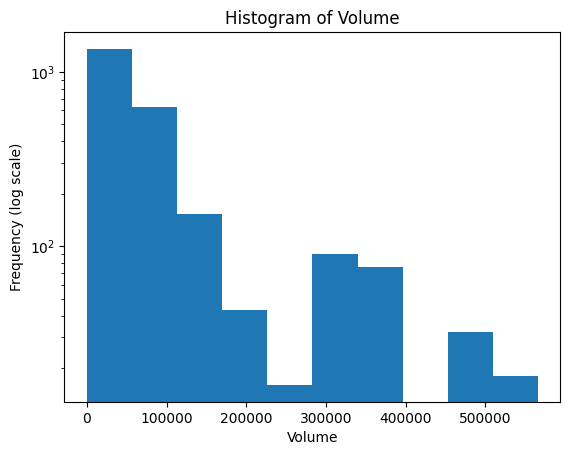

In [8]:
# histogram of volume
plt.hist(data['volume'])
plt.yscale('log')
plt.xlabel('Volume')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Volume')
plt.show()

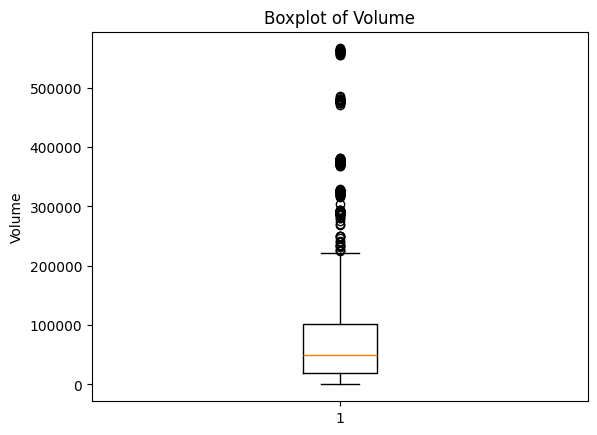

In [9]:
# boxplot of volume
plt.boxplot(data['volume'])
plt.ylabel('Volume')
plt.title('Boxplot of Volume')
plt.show()

In [10]:
# to learn more about the volume 
mean_volume = data['volume'].mean()
print("Mean volume (excluding zeros):", mean_volume)

Mean volume (excluding zeros): 84452.98963983366


If we had any doubts about the impact of zeros on volume, these visualizations have reassured us.

In [11]:
# descriptive statistics
data.describe()

,open,high,low,close,volume
count,2405.00000,2405.000000,2405.000000,2405.000000,2405.000000
mean,1.25443,1.256497,1.252416,1.254484,84452.989640
std,0.11951,0.119731,0.119187,0.119458,105049.085244
min,1.03936,1.040970,1.039340,1.040430,0.000000
25%,1.15448,1.157060,1.153670,1.154230,19336.349600
50%,1.24148,1.243820,1.238680,1.241500,49626.460000
75%,1.33930,1.341430,1.336750,1.338650,101106.199200
max,1.59245,1.593540,1.589980,1.591270,565936.890700


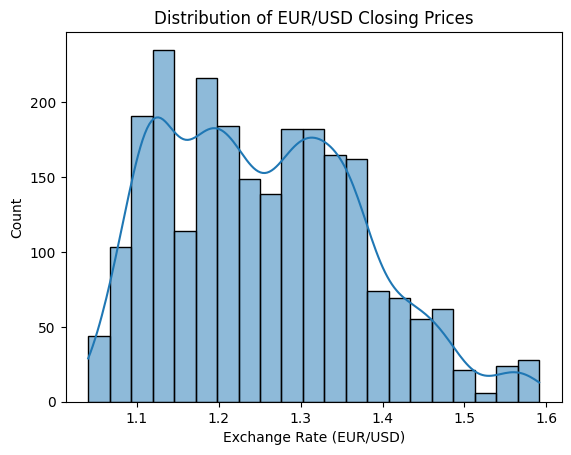

In [12]:
# Histogram of the distrubution of Euro and Dollar exchange rates (with AI)
sns.histplot(data['close'], kde=True)
plt.title("Distribution of EUR/USD Closing Prices")
plt.xlabel("Exchange Rate (EUR/USD)")
plt.show()

Now we will visualize the four different prices we have in our dataset. Visualizing closing prices, highest prices, lowest prices, and opening prices provides a better understanding of market behavior over the 18-year period covered by the dataset.

In [13]:
# to transform the 'Gmt time' column to datetime format
data['Gmt time'] = pd.to_datetime(data['Gmt time'],format = "%d.%m.%Y %H:%M:%S.%f")

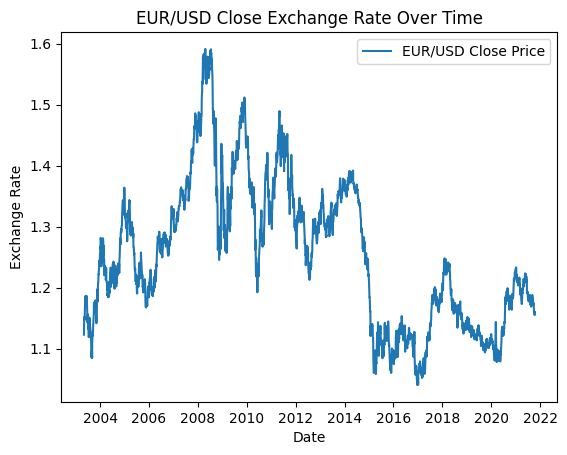

In [14]:
# Plot of close price every 4H over time 
plt.figure()
plt.plot(data['Gmt time'], data['close'], label='EUR/USD Close Price')
plt.title('EUR/USD Close Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

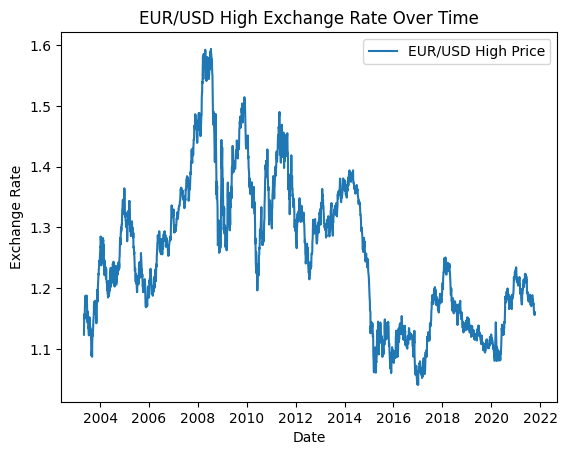

In [15]:
# Plot of highest price every 4H over time
plt.figure()
plt.plot(data["Gmt time"], data['high'], label='EUR/USD High Price')
plt.title('EUR/USD High Exchange Rate Over Time')
plt.xlabel("Date")
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

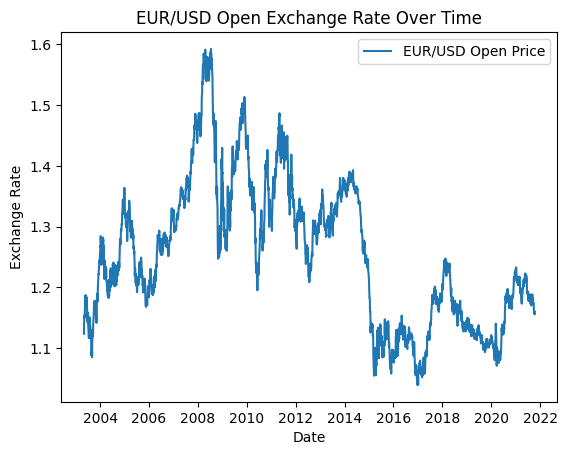

In [16]:
# Plot of open price every 4H over time
plt.figure()
plt.plot(data["Gmt time"], data['open'], label='EUR/USD Open Price')
plt.title('EUR/USD Open Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

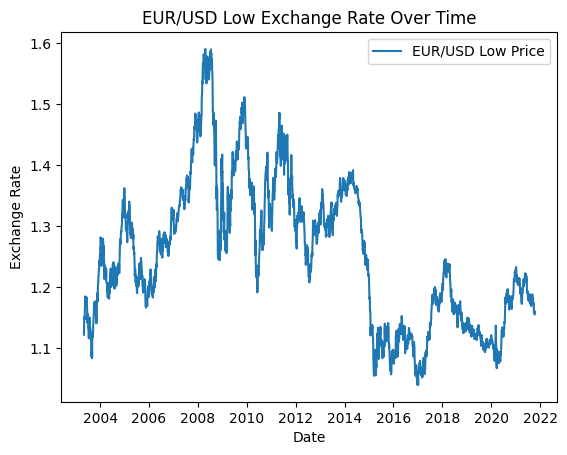

In [17]:
# Plot of Low price every 4H over time
plt.figure()
plt.plot(data["Gmt time"], data['low'], label='EUR/USD Low Price')
plt.title('EUR/USD Low Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

As we mentioned, the high, low, open, and close charts are similar. We will focus on and study the close price, which is most commonly used by professionals in the world of financial markets. 
So we can just keep gmt time, close price and volume for our analysis.


In [18]:
# cleaning the features and show the final data of part 2
data = data[['Gmt time', 'close', 'volume']]
data.head()

,Gmt time,close,volume
0,2003-05-04 21:00:00,1.12274,95533.0976
1,2003-05-06 21:00:00,1.14274,93442.5000
2,2003-05-08 21:00:00,1.15164,95166.0000
3,2003-05-12 21:00:00,1.15150,95618.9004
4,2003-05-14 21:00:00,1.14713,92479.4004


In [19]:
# to be safe
df = data.copy()

### Conclusion

Based on this exploratory analysis, we observed that:
- The dataset is clean and contains no missing or abnormal values.
- The price variables (open, high, low, close) are similar, which justifies focusing on the closing price for forecasting.
- The volume shows high variability but no anomalies, and can still provide useful information about market activity.

These observations confirm that the dataset is reliable and suitable for forecasting.
We will now move on to the next step.

# 3 - Feature Engineering

Afin d'améliorer la capacité prédictive de nos modèles, nous enrichissons l'ensemble de données avec des variables supplémentaires couramment utilisées dans l'analyse des séries chronologiques financières.
L'ensemble de données original ne contient que les cours et volumes, qui fournissent à eux seuls des informations limitées.

C'est pourquoi nous calculons plusieurs indicateurs techniques souvent utilisés par les analystes et les traders.

Technical indicators summarize price behavior over different time horizons and help models detect trends that are not immediately visible in the raw data.

In particular:
- Moving averages (MA5, MA20, etc.) capture short- and medium-term trends.
- Volatility measures (moving standard deviation) identify periods of greater uncertainty.
- RSI and MACD measure momentum and potential trend reversals.
- Volume averages and ratios provide information about market participation.

These indicators are well established in both academic literature and trading practice, and frequently improve performance in forecasting tasks.

Financial time series are strongly influenced by their recent past.
To allow models to capture this autoregressive behaviour, we add several lagged closing prices:

- Lag_1 = close at time t–1
- Lag_2 = close at time t–2
- ...

These features act as a short-term memory and provide essential information on recent market direction.

SO, we now compute all the technical indicators and lag features.
This step increases the dimensionality of the dataset and provides richer information for the machine learning models.

In [20]:
# add some indicators to the dataframe (with AI)
df['Return'] = df['close'].pct_change()

df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()

df['Volatility'] = df['Return'].rolling(10).std()

df['RSI'] = 100 - (100 / (1 + df['Return'].rolling(14).apply(lambda x: (x[x > 0].sum() / -x[x < 0].sum()) if -x[x < 0].sum() != 0 else 0)))

df["EMA12"] = df['close'].ewm(span=12, adjust=False).mean()
df["EMA26"] = df['close'].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA12"] - df["EMA26"]

df["VMA5"] = df['volume'].rolling(5).mean()
df["VMA20"] = df['volume'].rolling(20).mean()
df["Volume_Ratio"] = df["VMA5"] / df["VMA20"]

In [21]:
# add lagged features (with AI)
for lag in range(1, 6):  # 5 days of lag
    df[f'Lag_{lag}'] = df['close'].shift(lag)

To transform this problem into a supervised learning task, we define the target variable as the next closing price.
This means that for each observation at time t, the model will try to predict close(t+1) based on features available at time t.

In [22]:
# create target variable (next close price)
df["Target"] = df["close"].shift(-1)

Since rolling indicators and the target shifting introduce missing values at the beginning and end of the dataset, we remove these rows to obtain a clean and usable feature set.

In [23]:
# clean dataset
df = df.dropna()
print("\nNb de NaN restants par colonne :")
print(df.isna().sum())


Nb de NaN restants par colonne :
Gmt time        0
close           0
volume          0
Return          0
MA5             0
MA20            0
Volatility      0
RSI             0
EMA12           0
EMA26           0
MACD            0
VMA5            0
VMA20           0
Volume_Ratio    0
Lag_1           0
Lag_2           0
Lag_3           0
Lag_4           0
Lag_5           0
Target          0
dtype: int64


In [24]:
# show the final dataframe with all features
print("\nIndicator created :")
print(df.head())


Indicator created :
              Gmt time    close       volume    Return       MA5      MA20  \
19 2003-06-25 17:00:00  1.15398  370251.2969 -0.000269  1.169194  1.165625   
20 2003-06-27 17:00:00  1.14254  370356.6992 -0.009914  1.160442  1.166615   
21 2003-07-01 17:00:00  1.15608  373451.0000  0.011851  1.155784  1.167282   
22 2003-07-03 17:00:00  1.14945  379440.3985 -0.005735  1.151268  1.167172   
23 2003-07-07 17:00:00  1.13252  376872.7969 -0.014729  1.146914  1.166224   

    Volatility        RSI     EMA12     EMA26      MACD          VMA5  \
19    0.008060  44.583973  1.167028  1.158527  0.008501  374524.04222   
20    0.008282  37.844975  1.163261  1.157343  0.005918  374347.62114   
21    0.009513  45.663864  1.162156  1.157249  0.004907  373743.28050   
22    0.008878  34.788071  1.160201  1.156671  0.003530  373938.65862   
23    0.009366  32.967483  1.155943  1.154882  0.001060  374074.43830   

            VMA20  Volume_Ratio    Lag_1    Lag_2    Lag_3    Lag_4    

In [25]:
# we save the dataframe for xgboost
df_xgboost = df.copy()

### Conclusion 

Through this feature engineering process, we transformed the original dataset into a richer and more informative representation of the EUR/USD market.
We created indicators based on trends, momentum, volatility, and volume, as well as several lagged values to capture short-term price memory.
We also defined the target variable corresponding to the next closing price, which formalizes the forecasting problem as a supervised learning task.

After cleaning the dataset of missing values introduced by sliding windows and shifting, we now have a complete and consistent set of features, ready to be used for model training and evaluation.

# 4 - Train/Test Split and Preprocessing


Before training machine learning models, we need to prepare the dataset to ensure that the model cannot predict the future (no data leakage). 
Since we are working with financial time series, specific precautions are necessary regarding how we split and transform the data.

Be careful :
Unlike traditional machine learning tasks, we cannot shuffle the data (shuffle=false), because the temporal order contains essential information.
Mixing would allow the model to train on future values, which is unrealistic and would artificially inflate performance.

Therefore:
- the first 80% of the dataset will be used for training,
- the last 20% will be used for testing.

This configuration simulates a real forecasting scenario where past data is used to predict future observations.

In [26]:
#feature and target variable
X = df.drop(columns=["Target", "Return","Gmt time"])
y = df["Target"]

In [27]:
# split train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1908, 17)
Test shape: (477, 17)


Our dataset contains features with very different amplitudes.
To avoid biasing the models in favor of larger features, we apply normalization:

In [28]:
# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Conclusion

The data is correctly ordered, ensuring that there are no data leaks. All features are standardized. The dataset is ready.

We can now evaluate classic machine learning models to establish benchmark performance.

# 5 - Baseline Models

Before applying advanced algorithms such as XGBoost or ARIMA, it is necessary to evaluate a set of reference models.
Since financial time series are noisy and difficult to predict, simple models often give surprisingly good results.
This makes reference models particularly important.

We begin with several classic machine learning models commonly used for regression tasks.
Each model is evaluated using metrics such as:
- MAE – Mean Absolute Error
- RMSE – Root Mean Square Error
- R² Score – Proportion of variance explained

In [29]:
# models to test
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(),
    "SVR": SVR(kernel="rbf", C=1.0)
}
results = {}

In [30]:
# evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = [mae, rmse, r2]
    print("\n",name, " :")
    print("MAE: ", mae)
    print("RMSE: ", rmse)
    print("R2: ", r2)


 Linear Regression  :
MAE:  0.005237718004087756
RMSE:  0.006625460543236923
R2:  0.9755618433849248

 Random Forest  :
MAE:  0.005959939098532627
RMSE:  0.007411391812051044
R2:  0.9694201150929906

 Gradient Boosting  :
MAE:  0.005656801788402789
RMSE:  0.007257078876824115
R2:  0.9706802686490875

 Decision Tree  :
MAE:  0.010595303983228508
RMSE:  0.013267937883534945
R2:  0.901996145012082

 SVR  :
MAE:  0.0315133553031664
RMSE:  0.03637744984394369
R2:  0.2632828142144945


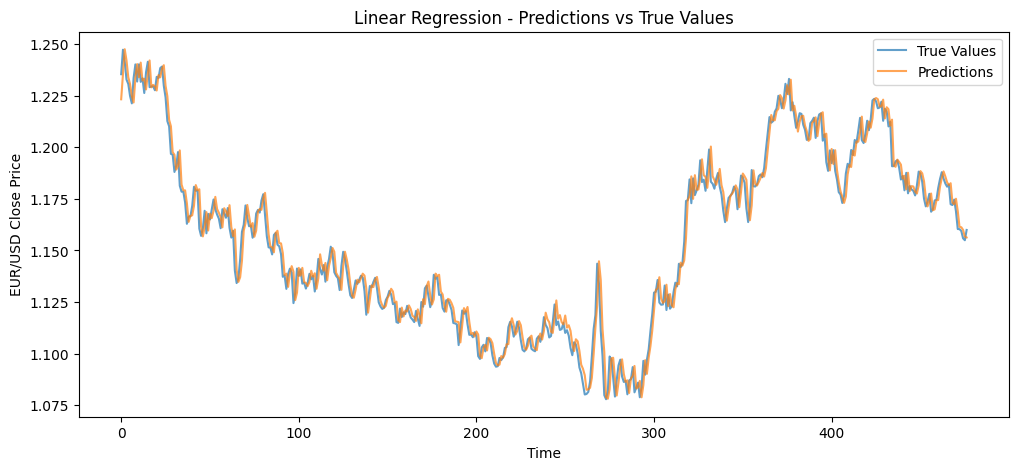

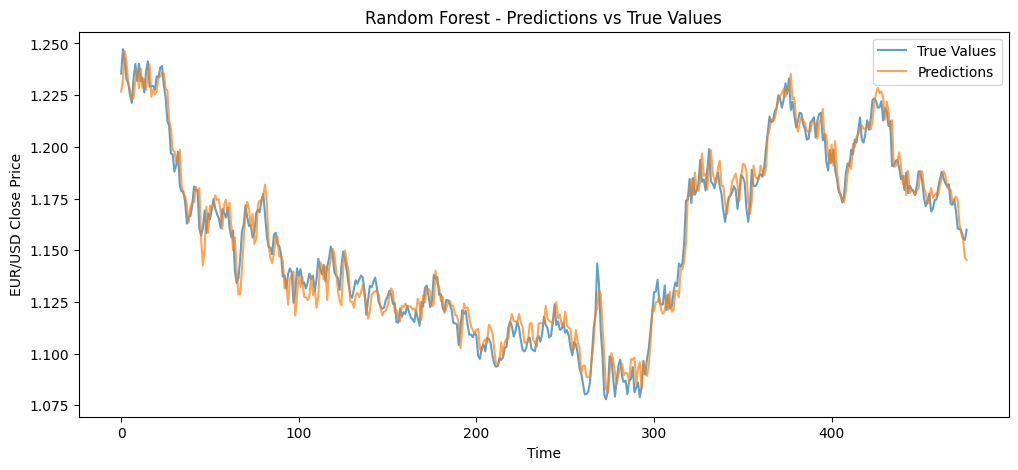

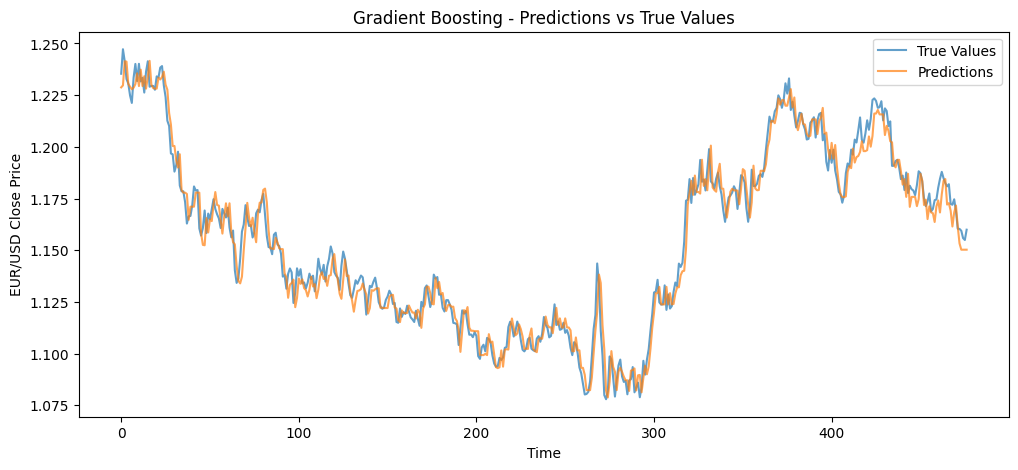

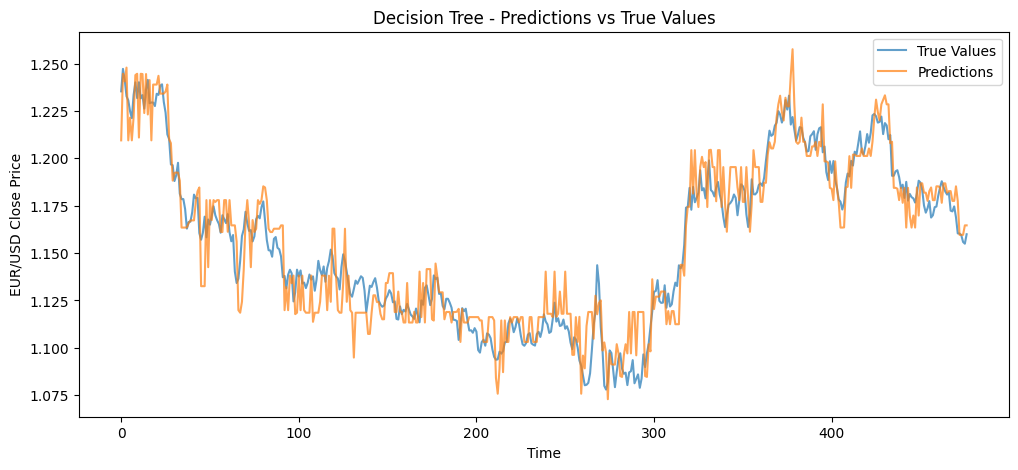

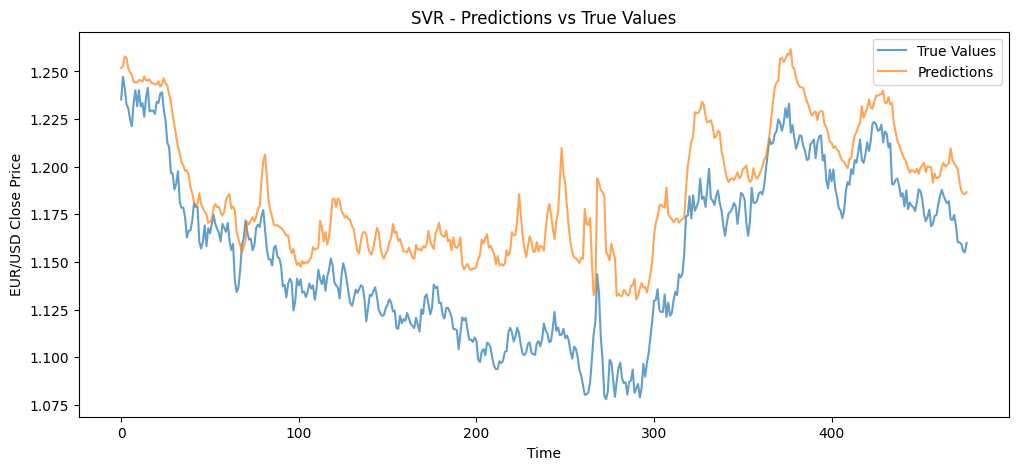

In [31]:
# plot of the results (with AI)
for name, model in models.items(): 
    # train again on full training set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    plt.figure(figsize=(12, 5))
    plt.plot(y_test.values, label="True Values", alpha=0.7)
    plt.plot(y_pred, label="Predictions", alpha=0.7)
    plt.title(f"{name} - Predictions vs True Values")
    plt.xlabel("Time")
    plt.ylabel("EUR/USD Close Price")
    plt.legend()
    plt.show()

In [32]:
# summarize results
results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T
print("\nPerformance Summary:")
print(results_df)


Performance Summary:
                        MAE      RMSE        R2
Linear Regression  0.005238  0.006625  0.975562
Random Forest      0.005960  0.007411  0.969420
Gradient Boosting  0.005657  0.007257  0.970680
Decision Tree      0.010595  0.013268  0.901996
SVR                0.031513  0.036377  0.263283


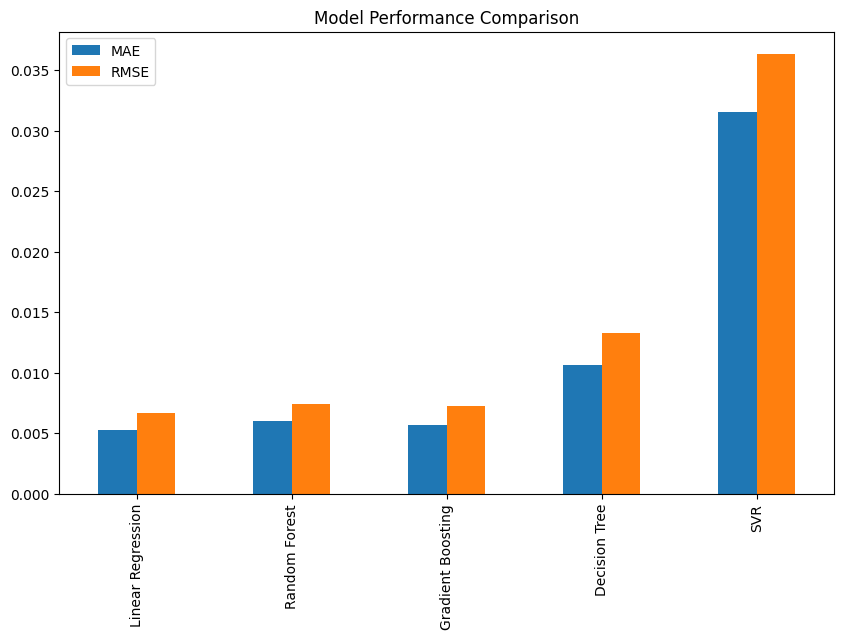

In [33]:
# plot to compare mae, rmse basic models (with AI)
results_df[["MAE", "RMSE"]].plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.show()


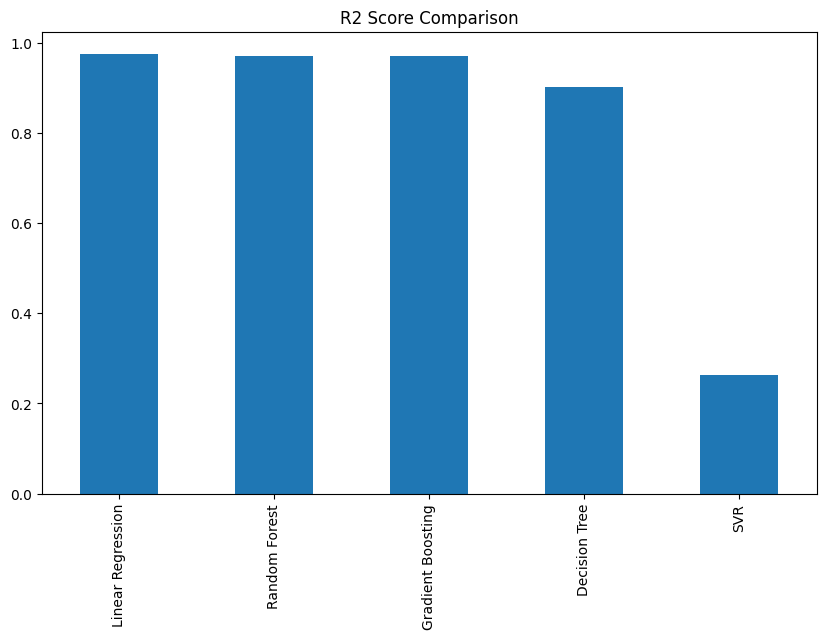

In [34]:
# plot to compare r2 basic models
results_df["R2"].plot(kind='bar', figsize=(10, 6))
plt.title("R2 Score Comparison")
plt.show()

### Conclusion

First, linear regression, random forest, and gradient boosting achieve very similar performance, with low MAE and RMSE values and R² scores close to 0.97.
This indicates that the technical features successfully capture a significant portion of the short-term structure of the data.

The decision tree model performs slightly worse, with higher error values and a lower R² score.
This is to be expected, as individual trees tend to overfit noisy time series and lack the stability of ensemble methods.

The SVR model clearly performs worse, with the highest MAE and RMSE values and an R² of only 0.26.
This means that margin-based methods struggle to handle the high noise and low stationarity of financial data, making them less suitable.

# 6 – ARIMA model

The ARIMA (Autoregressive Integrated Moving Average) model is one of the most widely used statistical models for forecasting univariate time series. It captures linear temporal dependencies through three parameters:
- p: autoregressive order
- d: differentiation order (to obtain stationarity)
- q: moving average order

The ARIMA model is traditionally applied to financial time series where short-term linear dependencies may exist, and is often used as a baseline before applying more advanced nonlinear models.
This approach is also supported by recent research, such as “Forecasting the EUR/USD Exchange Rate Using ARIMA and Machine Learning Models” (2024). 

Source : https://www.researchgate.net/publication/383543167_Forecasting_the_EURUSD_Exchange_Rate_Using_ARIMA_and_Machine_Learning_Models

However, the EUR/USD exchange rate is very noisy, non-stationary, and weakly autocorrelated, which limits the effectiveness of purely linear models such as ARIMA.
Testing ARIMA here allows us to evaluate its actual performance on Forex data and compare it with modern machine learning approaches.

In addition, we studied this model in another course this semester and wanted to test it.
We thought it would be interesting to use it here.
However, we must be careful because ARIMA is a univariate model, so it can only use a single variable. Here, we will use the close.

In [35]:
# load data
df = pd.read_csv("Data_EURUSD_4h.csv")
df['Gmt time'] = pd.to_datetime(df['Gmt time'],format = "%d.%m.%Y %H:%M:%S.%f")
df.head()


,Gmt time,open,high,low,close,volume
0,2003-05-04 21:00:00,1.12354,1.12354,1.12166,1.12274,95533.0976
1,2003-05-05 01:00:00,1.12242,1.12276,1.12067,1.12126,93778.5996
2,2003-05-05 05:00:00,1.12139,1.12255,1.12030,1.12113,90924.6992
3,2003-05-05 09:00:00,1.12092,1.12331,1.12049,1.12174,91254.6992
4,2003-05-05 13:00:00,1.12194,1.12900,1.12130,1.12712,308003.4083


In [36]:
# we define juste one variable to work with ARIMA
series = df["close"]

In [37]:
# split data
test_size = 100
train, test = series[:-test_size], series[-test_size:]

In [38]:
# check stationarity (ADF test)
result = adfuller(train)
if result[1] < 0.05:
    d = 0 # we rejet the null hypothesis and the series is stationary
else:
    d = 1
print("Selected differencing order d =", d)

Selected differencing order d = 1


In [39]:
# grid search for (p,d,q)
warnings.filterwarnings("ignore")
best_aic = np.inf
best_order = None
best_model = None

p_range = range(0, 6)
q_range = range(0, 6)


for p in p_range: 
    for q in q_range:
        try: # with AI
            model = ARIMA(train, order=(p, d, q))
            model_fit = model.fit()
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, d, q)
                best_model = model_fit
        except:
            continue

print("\nBest ARIMA order: ",best_order," with AIC = ", best_aic)


Best ARIMA order:  (4, 1, 0)  with AIC =  -252510.53663538728


In [40]:
# summary
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                28760
Model:                 ARIMA(4, 1, 0)   Log Likelihood              126260.268
Date:                Thu, 11 Dec 2025   AIC                        -252510.537
Time:                        09:40:57   BIC                        -252469.203
Sample:                             0   HQIC                       -252497.248
                              - 28760                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0038      0.004      0.962      0.336      -0.004       0.012
ar.L2          0.0072      0.004      1.633      0.103      -0.001       0.016
ar.L3         -0.0185      0.005     -3.741      0.0

Based on ARIMA(4, 1, 0), we can say several things:

Of the four autoregressive coefficients, only ar.L3 and ar.L4 are statistically significant (p-values < 0.05).
This means that most of the linear dependencies in the model are weak or unstable.

The sigma² value is very high, which means that the residual noise is significant.

The Ljung-Box test (Q = 0, p = 1.00) suggests that the residuals still contain autocorrelation, which means that the model does not fully explain the structure of a series.

The extremely high Jarque-Bera statistic and skewness/kurtosis values show that the residuals are far from a normal distribution, which violates the ARIMA assumptions.

Overall, the diagnostic indicators confirm that the ARIMA model is not well suited to the EUR/USD series, which is to be expected for a highly noisy and weakly autocorrelated financial market.

We can therefore expect a poor R².


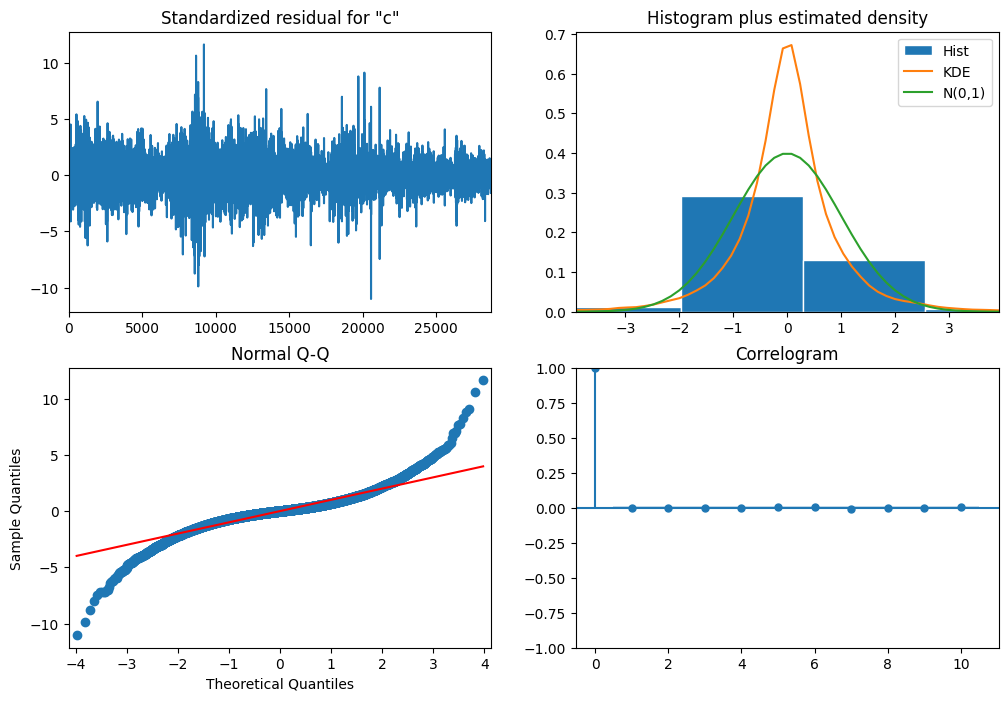

In [41]:
#diagnose the model (with AI)
best_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [42]:
#forecast
forecast = best_model.forecast(steps=test_size)

In [43]:
# evaluation
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print("RMSE: ", rmse)
print("MAE: ", mae)
print("R²: ",  r2)

RMSE:  0.011509356343526194
MAE:  0.010240396088222761
R²:  -2.6443153436942337


A negative R² means that the model performs worse than simply predicting the mean of the test set.
This confirms that ARIMA fails to capture the dynamics of the EUR/USD series.

As mentioned earlier, the EUR/USD exchange rate is very noisy, non-stationary, and weakly autocorrelated.
Since the ARIMA model does not satisfy its underlying assumptions, it is not suitable for forecasting in this context.

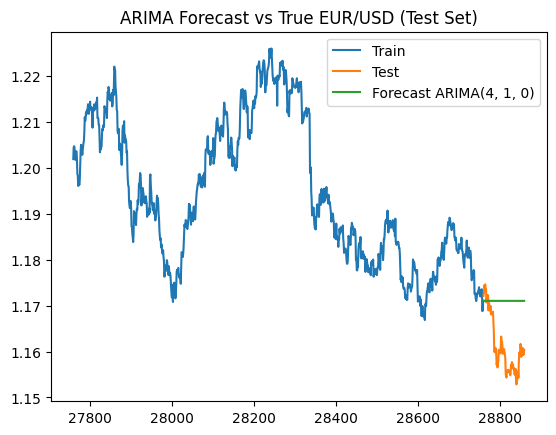

In [44]:
# we can zoom to see better
plt.figure()
plt.plot(train[-1000:], label="Train")
plt.plot(test[-1000:], label="Test")
plt.plot(test.index[-1000:], forecast, label=f"Forecast ARIMA{best_order}")
plt.legend()
plt.title("ARIMA Forecast vs True EUR/USD (Test Set)")
plt.show()

### Conclusion 

In summary, although ARIMA is a classic benchmark for time series forecasting, its performance is really poor when it comes to the EUR/USD exchange rate.
The model violates its underlying assumptions, fails to capture the dynamics of the series, and even performs worse than predicting the mean.
These results confirm that linear statistical models are not suitable for short-term forecasting in the foreign exchange market, which is why we will look at another well-known model in financial markets.

# 7 – XGBoost Model

After evaluating classic machine learning and ARIMA models, we use XGBoost, an algorithm well known for its high performance.

XGBoost is particularly relevant in our context because:
It captures nonlinear relationships between features.
It handles the complex interactions created by our technical indicators.
It is robust to noise, which is essential for financial time series.
It often outperforms linear and tree-based benchmarks in forecasting tasks.

We can also justify the use of this model thanks to this link: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4450688

XGBoost was also used for its ability to model noisy markets.

In this section, we train XGBoost, tune its hyperparameters, and evaluate its performance.

In [45]:
#import dataframe for xgboost
df = df_xgboost

In [46]:
# data augmentation for pattern features and recognitions

df_upgrade = pd.DataFrame()
df_upgrade["Time"] = df["Gmt time"]
df_upgrade["close"] = df["close"]
df_upgrade["volume"] = df["volume"]

#adding moving average
df_upgrade["MA_5"] = df_upgrade["close"].shift(1).rolling(5).mean()
df_upgrade["MA_50"] = df_upgrade["close"].shift(1).rolling(50).mean()
df_upgrade["MA_250"] = df_upgrade["close"].shift(1).rolling(250).mean()

#with AI
#adding std that serves as volatility 
df_upgrade["std_5"] = df_upgrade["close"].shift(1).rolling(5).std()
df_upgrade["std_50"] = df_upgrade["close"].shift(1).rolling(50).std()
df_upgrade["std_250"] = df_upgrade["close"].shift(1).rolling(250).std()

#adding returns
df_upgrade["returns_1"] = ((df_upgrade["close"]-df_upgrade["close"].shift(1))/df_upgrade['close'].shift(1))
df_upgrade["returns_5"] = ((df_upgrade["close"]-df_upgrade["close"].shift(5))/df_upgrade['close'].shift(5))
df_upgrade["returns_50"] = ((df_upgrade["close"]-df_upgrade["close"].shift(50))/df_upgrade['close'].shift(50))
df_upgrade["returns_250"] = ((df_upgrade["close"]-df_upgrade["close"].shift(250))/df_upgrade['close'].shift(250))

#adding volatility
df_upgrade["volatility_5"]  = df_upgrade["returns_1"].shift(1).rolling(5).std()
df_upgrade["volatility_50"]  = df_upgrade["returns_1"].shift(1).rolling(50).std()
df_upgrade["volatility_250"] = df_upgrade["returns_1"].shift(1).rolling(250).std()


df_upgrade = df_upgrade.dropna(axis = 0).reset_index(drop = True)

df_upgrade.head(5)

,Time,close,volume,MA_5,MA_50,MA_250,std_5,std_50,std_250,returns_1,returns_5,returns_50,returns_250,volatility_5,volatility_50,volatility_250
0,2005-05-27 05:00:00,1.25350,102106.0996,1.261764,1.300618,1.232826,0.005566,0.020404,0.063667,-0.002975,-0.009748,-0.050976,0.097117,0.008301,0.007819,0.008728
1,2005-05-31 05:00:00,1.23865,101853.7012,1.259296,1.299271,1.233270,0.006023,0.021247,0.063421,-0.011847,-0.021495,-0.057581,0.071422,0.004316,0.007821,0.008706
2,2005-06-02 05:00:00,1.22833,100714.3984,1.253854,1.297758,1.233600,0.009750,0.022792,0.063232,-0.008332,-0.029425,-0.071220,0.068624,0.005926,0.007952,0.008710
3,2005-06-06 05:00:00,1.22840,103024.7012,1.246406,1.295874,1.233915,0.012420,0.024530,0.063007,0.000057,-0.020657,-0.062161,0.084661,0.005627,0.007942,0.008719
4,2005-06-08 05:00:00,1.23123,103622.6016,1.241224,1.294246,1.234299,0.013643,0.026229,0.062679,0.002304,-0.020688,-0.059649,0.084966,0.005871,0.007857,0.008667


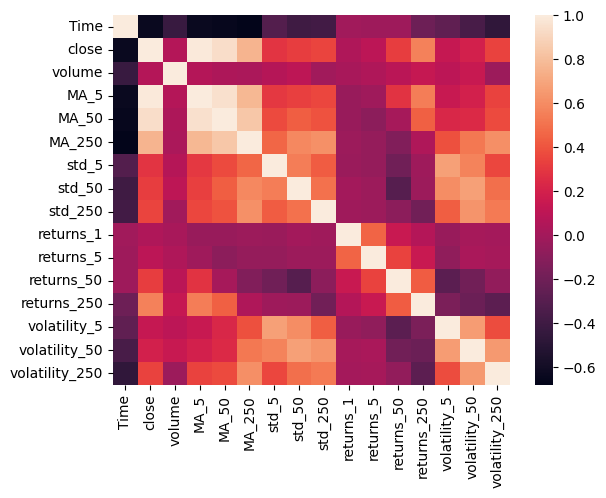

In [47]:
#Evaluate the correlation between the features 
sns.heatmap(df_upgrade.corr())
plt.show()

We can notice that the close price is mostly correlated with moving average as expected from a pretty stable exchange pair. We also notice that its slightly correlated to the returns and volatility.

In [48]:
#Split time periods for training 

rows = len(df_upgrade)
split_index = int(rows*0.8)

df_train = df_upgrade.iloc[:split_index]
df_validation = df_upgrade.iloc[split_index:]

X_train = df_train.drop(['close','Time'],axis = 'columns')
y_train = df_train['close']

X_test = df_validation.drop(['close','Time'],axis = 'columns')
y_test = df_validation['close']


In [49]:
#scaling

scaler = StandardScaler()

scaler.fit(X_train)

X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [50]:
#XGBRegressor hyperparameters fitting

xgb = XGBRegressor(random_state = 0)

#most efficient data structure for the xgboost regressor
data = DMatrix(data = X_train, label = y_train)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2], 
    'n_estimators': [100, 250, 500],

    'max_depth': [3, 5, 7],  
    'min_child_weight': [1, 3, 5], 
    
    'subsample': [0.5, 0.7, 1.0], 
    'colsample_bytree': [0.5, 0.7, 1.0], 
}

grid_search = GridSearchCV(estimator = xgb,
                           param_grid = param_grid,
                           scoring = "neg_mean_squared_error",
                           cv =4,
                           verbose = 1,
                           n_jobs = -1)

grid_search.fit(X_train,y_train)

print("Best parameters for XGBRegressor:", grid_search.best_params_)
print("Best MSE for XGBRegressor:", -grid_search.best_score_)


Fitting 4 folds for each of 729 candidates, totalling 2916 fits
Best parameters for XGBRegressor: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 250, 'subsample': 0.5}
Best MSE for XGBRegressor: 0.00043088692872232334


In [51]:
xgb_best = grid_search.best_estimator_

xgb_best.fit(X_train,y_train)

y_pred = xgb_best.predict(X_test)

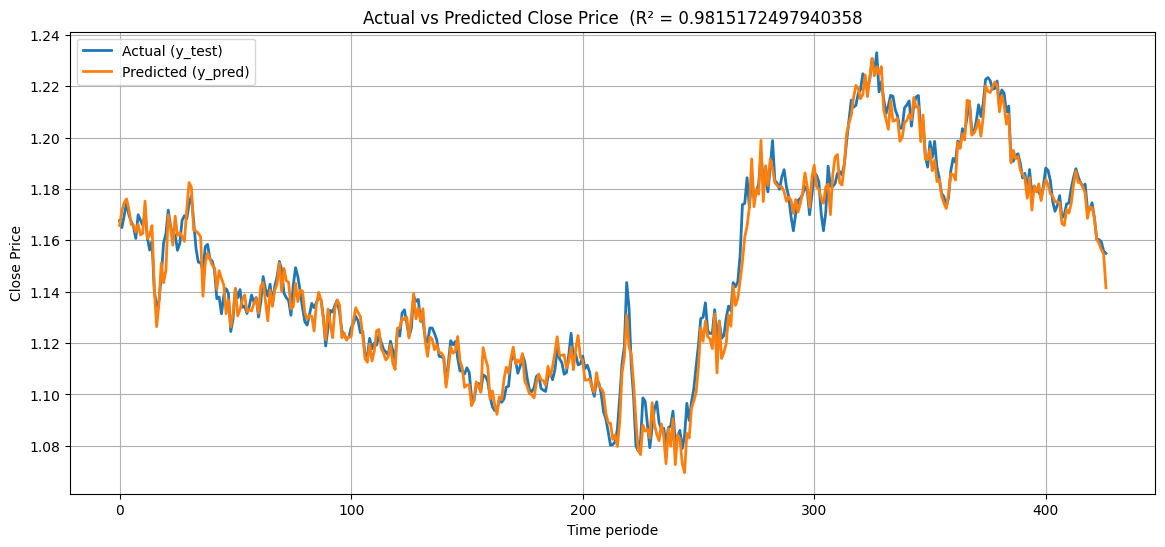

In [52]:
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(14,6)) #with AI

plt.plot(y_test.values, label="Actual (y_test)", linewidth=2)
plt.plot(y_pred, label="Predicted (y_pred)", linewidth=2)

plt.title("Actual vs Predicted Close Price  (R² = {}".format(r2))
plt.xlabel("Time periode")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)


We noticed afterward that there may be some data leakage 


In [53]:
#shift the target by one time period to predict indeed H+4 instead of allowing the model to just reverse engineer the close price from the leaking moving average

df_upgrade["target"] = df_upgrade["close"].shift(-1)
df_upgrade = df_upgrade.dropna().reset_index(drop=True)

X = df_upgrade.drop(["Time", "close", "target"], axis=1)
y = df_upgrade["target"]

rows = len(df_upgrade)
split_index = int(rows * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

In [54]:
scaler = StandardScaler()

scaler.fit(X_train)

X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [55]:
xgb = XGBRegressor(random_state = 0)

#most efficient data structure for the xgboost regressor
data = DMatrix(data = X_train, label = y_train)


param_grid = {
    'learning_rate': [0.01, 0.1, 0.2], 
    'n_estimators': [100, 250, 500],

    'max_depth': [3, 5, 7],  
    'min_child_weight': [1, 3, 5], 
    
    'subsample': [0.5, 0.7, 1.0], 
    'colsample_bytree': [0.5, 0.7, 1.0], 
}
grid_search = GridSearchCV(estimator = xgb,
                           param_grid = param_grid,
                           scoring = "neg_mean_squared_error",
                           cv =4,
                           verbose = 1,
                           n_jobs = -1)

grid_search.fit(X_train,y_train)

print("Best parameters for XGBRegressor:", grid_search.best_params_)
print("Best MSE for XGBRegressor:", -grid_search.best_score_)

Fitting 4 folds for each of 729 candidates, totalling 2916 fits
Best parameters for XGBRegressor: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 250, 'subsample': 1.0}
Best MSE for XGBRegressor: 0.0008531066341369593


In [56]:
xgb_best = grid_search.best_estimator_

xgb_best.fit(X_train,y_train)

y_pred = xgb_best.predict(X_test)

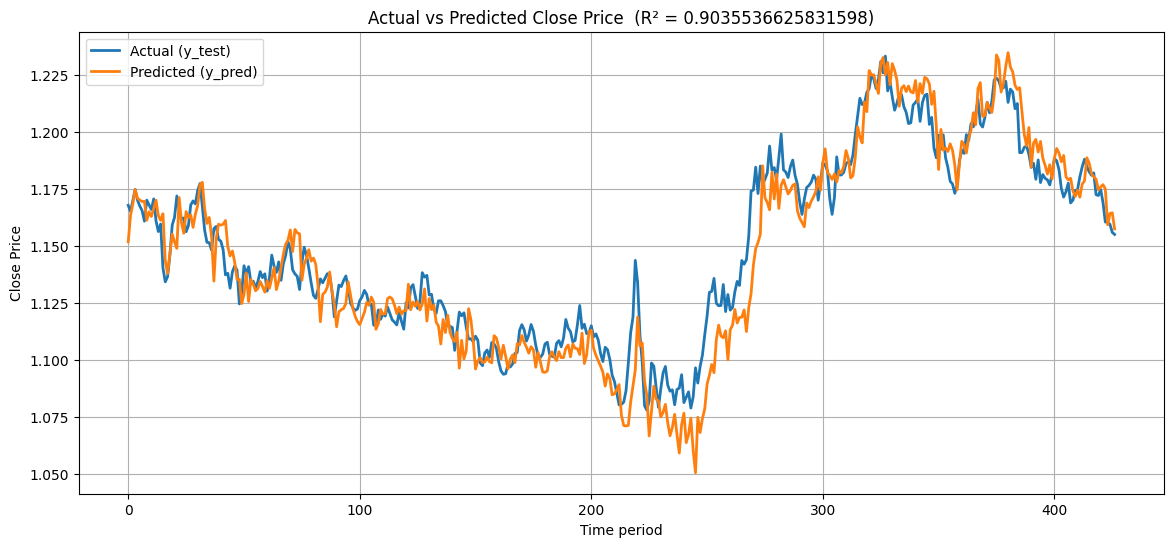

In [57]:
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(14,6)) #with AI

plt.plot(y_test.values, label="Actual (y_test)", linewidth=2)
plt.plot(y_pred, label="Predicted (y_pred)", linewidth=2)

plt.title("Actual vs Predicted Close Price  (R² = {})".format(r2))
plt.xlabel("Time period")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)

Removing the data leakage slightly reduced de R2 score but since we gave enough features the model is still able to perform correctly for this exchange rate since it's pretty stable.
In our case eur/usd is probably too stable and the model is over complicating the prediction compared to linear regression that takes a more basic approach to predict the next closing price.




# Conclusion


In [58]:
# Summary of R² models
print("Summary of R² models :")
print("Basic models :")
print(results_df["R2"])
print("\nAdvanded model :")
print("R2 =", r2)

Summary of R² models :
Basic models :
Linear Regression    0.975562
Random Forest        0.969420
Gradient Boosting    0.970680
Decision Tree        0.901996
SVR                  0.263283
Name: R2, dtype: float64

Advanded model :
R2 = 0.9035536625831598


In summary, this study shows that while advanced models such as XGBoost offer a real ability to capture the complexity of financial series, simpler approaches such as linear regression remain surprisingly effective for an asset as stable as EUR/USD. 

These results highlight the importance of choosing a model that is suited to the characteristics of the market being analyzed, while also reminding us of the inherent limitations of forecasting highly noisy data.